# Cost Taxonomy and Fee Schedules

**Docker image**: `ml4t`

This notebook maps the transaction cost landscape across our six
liquid-market groups, comparing exchange fee structures, spread regimes,
and the resulting breakeven alpha requirements for each case study.
Options costs are handled separately in NB02/NB03; NASDAQ-100 minute bars
are deferred to the microstructure analysis there.

**Learning Objectives:**
- Survey real exchange fee schedules (Binance, CME, IB, OANDA)
- Compute ADV distributions per asset class to gauge available liquidity
- Identify which cost component (spread, commission, impact) dominates at
  different trade sizes
- Load all nine setup.yaml cost assumptions and assess their realism
- Calculate breakeven alpha for each case study given its cost and turnover profile

**Book Reference:** Chapter 18, Sections 18.1 (Why Costs Matter) and
18.2 (Cost Components)

**Prerequisites:** Access to all six OHLCV datasets covered here and
case study `config/setup.yaml` files.

In [1]:
"""Cost Taxonomy & Fee Schedules — cross-asset cost decomposition and breakeven analysis."""

import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import yaml
from _cost_analysis import (
    FEE_SCHEDULES,
    breakeven_alpha,
    standardized_cost_per_100k,
)

from data import (
    load_cme_futures,
    load_crypto_perps,
    load_etfs,
    load_fx_pairs,
    load_sp500_daily_bars,
    load_us_equities,
)
from utils.paths import get_case_study_source_dir

In [2]:
MAX_SYMBOLS = 0  # 0 = all symbols

## 1. Liquidity Landscape: ADV Distributions

Average daily volume (ADV) determines how much a strategy can trade before
market impact becomes the dominant cost. We compute ADV distributions
across all six liquid-market groups.

In [3]:
def keep_top_symbols(df: pl.DataFrame, symbol_col: str) -> pl.DataFrame:
    """Optionally restrict a dataset to the most liquid symbols."""
    if MAX_SYMBOLS <= 0:
        return df
    top = df.group_by(symbol_col).agg(pl.col("volume").mean()).sort("volume", descending=True)
    return df.filter(pl.col(symbol_col).is_in(top.head(MAX_SYMBOLS)[symbol_col]))

### ADV Aggregation Helper

**Interpretation**: This helper standardizes liquidity measurement before we compare
markets. Using the same ADV definition across datasets ensures later differences reflect
genuine market structure rather than inconsistent preprocessing.

In [4]:
def make_adv_frame(df: pl.DataFrame, symbol_col: str, asset_class: str) -> pl.DataFrame:
    """Compute average daily dollar volume for one asset class."""
    return (
        df.group_by(symbol_col)
        .agg(adv_usd=(pl.col("volume") * pl.col("close")).mean())
        .rename({symbol_col: "symbol"})
        .with_columns(asset_class=pl.lit(asset_class))
        .select("symbol", "adv_usd", "asset_class")
    )

### Load Each Asset Class and Standardize ADV

In [5]:
adv_records = []

# ETFs
adv_records.append(make_adv_frame(keep_top_symbols(load_etfs(), "symbol"), "symbol", "ETFs"))

# Crypto Perps
adv_records.append(
    make_adv_frame(
        keep_top_symbols(load_crypto_perps(frequency="8h"), "symbol"),
        "symbol",
        "Crypto Perps",
    )
)

# CME Futures (front month). Dollar ADV = volume × *traded* price, so feed the
# raw (unadjusted) close as `close`; adjusted levels would misstate early-year notional.
adv_records.append(
    make_adv_frame(
        keep_top_symbols(load_cme_futures(tenors=[0]), "product").rename({"raw_close": "close"}),
        "product",
        "CME Futures",
    )
)

### Add FX and Equity Datasets

In [6]:
# FX Pairs (daily)
fx = load_fx_pairs(frequency="daily")
if MAX_SYMBOLS > 0:
    fx = fx.filter(pl.col("symbol").is_in(fx["symbol"].unique().sort().head(MAX_SYMBOLS)))
adv_records.append(make_adv_frame(fx, "symbol", "FX Pairs"))

# US Equities
adv_records.append(
    make_adv_frame(keep_top_symbols(load_us_equities(), "symbol"), "symbol", "US Equities")
)

# S&P 500 Daily
adv_records.append(
    make_adv_frame(
        keep_top_symbols(load_sp500_daily_bars(), "symbol"),
        "symbol",
        "S&P 500 Equities",
    )
)

# Note: NASDAQ-100 minute bars omitted — S&P 500 daily bars already
# covers large-cap US equities. See NB02/NB03 for microstructure analysis.

all_adv = pl.concat(adv_records)

**Note**: FX volume comes from the OANDA retail platform and reflects retail order
flow, not the institutional interdealer market (~$7.5 trillion/day). FX ADV here
understates true institutional liquidity by several orders of magnitude. The
remaining asset classes use exchange-reported volume that scales with actual
market activity.

In [7]:
adv_summary = (
    all_adv.group_by("asset_class")
    .agg(
        n_symbols=pl.col("symbol").n_unique(),
        median_adv_usd=pl.col("adv_usd").median(),
        p25_adv_usd=pl.col("adv_usd").quantile(0.25),
        p75_adv_usd=pl.col("adv_usd").quantile(0.75),
    )
    .sort("median_adv_usd", descending=True)
)
adv_summary

asset_class,n_symbols,median_adv_usd,p25_adv_usd,p75_adv_usd
str,u32,f64,f64,f64
"""ETFs""",100,1.6233e8,7.3248e7,3.8750e8
"""S&P 500 Equities""",638,1.5994e8,1.0420e8,2.8571e8
"""Crypto Perps""",19,1.1838e8,5.2622e7,3.4416e8
"""US Equities""",3199,8.1978e6,2.4623e6,2.7960e7
"""CME Futures""",30,7.7005e6,183061.023319,8.5170e7
"""FX Pairs""",20,132990.11981,80508.741991,7.9724e6


**Finding**: The tabular ADV summary gives the numeric anchor behind the later
figures. It shows why a single cost assumption cannot span futures, crypto, FX,
and smaller equity universes without becoming misleading.

### ADV Distribution Violin Plot

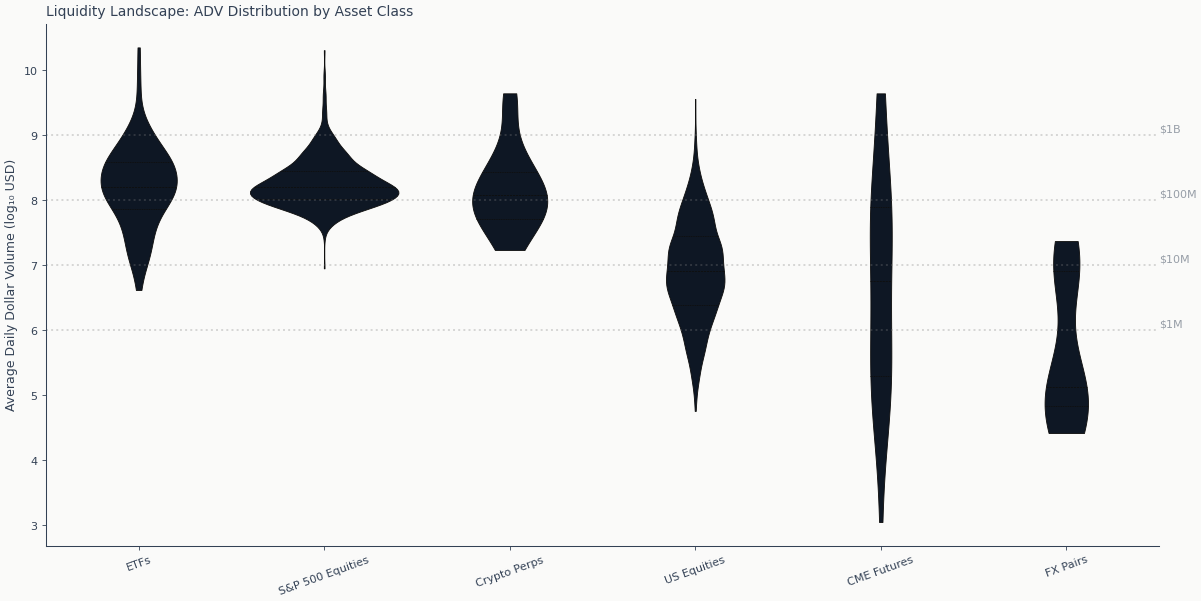

In [8]:
adv_pd = all_adv.filter(pl.col("adv_usd") > 0).to_pandas()
adv_pd["log_adv_usd"] = np.log10(adv_pd["adv_usd"])

order = (
    all_adv.group_by("asset_class")
    .agg(pl.col("adv_usd").median())
    .sort("adv_usd", descending=True)["asset_class"]
    .to_list()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(
    data=adv_pd,
    x="asset_class",
    y="log_adv_usd",
    order=order,
    ax=ax,
    inner="quartile",
    cut=0,
)
ax.set_ylabel("Average Daily Dollar Volume (log₁₀ USD)")
ax.set_xlabel("")
ax.set_title("Liquidity Landscape: ADV Distribution by Asset Class")
ax.tick_params(axis="x", rotation=20)

# Add reference lines
for val, label in [(6, "$1M"), (7, "$10M"), (8, "$100M"), (9, "$1B")]:
    ax.axhline(val, color="gray", linestyle=":", alpha=0.3)
    ax.text(len(order) - 0.5, val + 0.05, label, fontsize=8, alpha=0.5)

fig.show()

**Finding**: Exchange-reported ADV spans several orders of magnitude across
asset classes. ETFs and S&P 500 components have median ADV above $100M;
smaller US equities and CME futures products are in the low millions.
FX appears illiquid here because OANDA volumes reflect retail flow only —
institutional FX is far more liquid than any equity market.
This ADV dispersion determines which cost component dominates and the
strategy's capacity ceiling.

## 2. Exchange Fee Schedules

We codify actual exchange fee structures for cross-asset comparison.

In [9]:
# Flatten the codified fee schedules into one row per (venue, fee component).
# The raw dict remains accessible as `FEE_SCHEDULES` for ad-hoc inspection.
fee_rows = [
    {"venue": schedule["name"], "component": k, "value": v}
    for schedule in FEE_SCHEDULES.values()
    for k, v in schedule.items()
    if k not in ("name", "notes")
]
fee_schedule_df = pl.DataFrame(fee_rows)
fee_schedule_df

venue,component,value
str,str,str
"""US Equities (IB Pro)""","""commission_per_share""","""0.005"""
"""US Equities (IB Pro)""","""min_commission""","""1"""
"""US Equities (IB Pro)""","""sec_fee_per_million""","""27.8"""
"""US Equities (IB Pro)""","""finra_taf_per_share""","""0.000166"""
"""US Equities (IB Pro)""","""exchange_rebate_per_share""","""-0.002"""
…,…,…
"""FX Spot (OANDA-style)""","""swap_points_note""","""Overnight roll cost varies by …"
"""US Equity Options (IB Pro)""","""commission_per_contract""","""0.65"""
"""US Equity Options (IB Pro)""","""min_commission""","""1"""


### Standardized Cost per $100K Trade

**Interpretation**: The raw fee-schedule dump matters because it feeds the standardized
notional comparison below. Translating heterogeneous exchange rules into the same `$100K`
trade lens is what makes cross-venue fee comparisons economically meaningful.

In [10]:
asset_classes = ["us_equities", "etfs", "crypto_perps", "cme_futures", "fx_spot", "sp500_options"]
std_costs = []
for ac in asset_classes:
    result = standardized_cost_per_100k(ac)
    result["asset_class"] = FEE_SCHEDULES[ac]["name"]
    std_costs.append(result)

std_df = pl.DataFrame(std_costs).sort("total_bps", descending=True)
std_df

commission_bps,exchange_bps,total_bps,asset_class
f64,f64,f64,str
13.0,7.1,20.1,"""US Equity Options (IB Pro)"""
4.0,0.0,4.0,"""Crypto Perpetuals (Binance)"""
1.0,0.88,1.88,"""US Equities (IB Pro)"""
1.0,0.88,1.88,"""ETFs (IB Pro)"""
0.0,1.5,1.5,"""FX Spot (OANDA-style)"""
0.27,0.22,0.48,"""CME Futures"""


**Finding**: Standardizing everything to cost per `$100K` trade makes cross-asset
comparisons possible. Once notional is held constant, fees stop looking like a
venue-specific detail and become directly comparable with spread and impact drag.

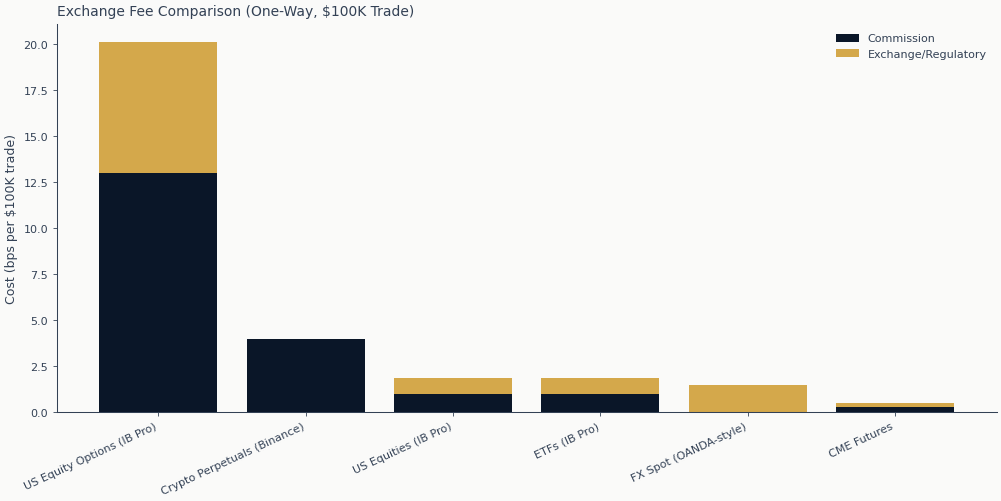

In [11]:
# Stacked bar chart of fee components
std_pd = std_df.to_pandas()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(std_pd))
ax.bar(x, std_pd["commission_bps"], label="Commission")
ax.bar(x, std_pd["exchange_bps"], bottom=std_pd["commission_bps"], label="Exchange/Regulatory")
ax.set_xticks(x)
ax.set_xticklabels(std_pd["asset_class"], rotation=25, ha="right")
ax.set_ylabel("Cost (bps per $100K trade)")
ax.set_title("Exchange Fee Comparison (One-Way, $100K Trade)")
ax.legend()

fig.show()

**Finding**: Per-share and per-contract fee structures (equities, futures)
translate to modest costs at $100K trade sizes. Options stand out because
per-contract fees compound across many small-premium contracts. The bid-ask
spread and market impact — not exchange fees — dominate total costs for most
asset classes. Crypto taker fees (4 bps) are higher than equity commissions
but lower than typical equity spreads.

## 3. Cost Component Dominance

Which cost component (commission, spread, or market impact) dominates
depends on trade size. We model this tradeoff for each asset class.

In [12]:
trade_sizes = np.logspace(3, 8, 50)  # $1K to $100M

In [13]:
cost_params = {
    "ETFs": {
        "commission_bps": 1.0,
        "spread_bps": 3.0,
        "impact_eta": 0.05,
        "sigma": 0.015,
        "adv_usd": 5e8,
    },
    "Crypto Perps": {
        "commission_bps": 4.0,
        "spread_bps": 2.0,
        "impact_eta": 0.03,
        "sigma": 0.04,
        "adv_usd": 1e9,
    },
    "CME Futures": {
        "commission_bps": 1.5,
        "spread_bps": 1.5,
        "impact_eta": 0.04,
        "sigma": 0.01,
        "adv_usd": 2e9,
    },
    "FX Pairs": {
        "commission_bps": 0.0,
        "spread_bps": 2.0,
        "impact_eta": 0.02,
        "sigma": 0.005,
        "adv_usd": 5e9,
    },
}

In [14]:
cost_params |= {
    "S&P 500": {
        "commission_bps": 1.0,
        "spread_bps": 2.0,
        "impact_eta": 0.05,
        "sigma": 0.015,
        "adv_usd": 1e8,
    },
    "US Equities": {
        "commission_bps": 1.0,
        "spread_bps": 8.0,
        "impact_eta": 0.10,
        "sigma": 0.025,
        "adv_usd": 5e6,
    },
}

### Cost-Component Helper

In [15]:
def cost_components(size: float, params: dict) -> dict:
    """Compute commission, spread, and square-root impact in basis points."""
    participation = size / params["adv_usd"]
    impact = params["impact_eta"] * params["sigma"] * np.sqrt(participation) * 10_000
    return {
        "Commission": params["commission_bps"],
        "Spread": params["spread_bps"],
        "Impact": impact,
    }

### Map the Dominant Cost Component by Trade Size

In [16]:
dominance_rows = []
size_labels = ["$10K", "$100K", "$1M", "$10M", "$100M"]
size_values = [1e4, 1e5, 1e6, 1e7, 1e8]

for asset, params in cost_params.items():
    for size, label in zip(size_values, size_labels, strict=False):
        costs = cost_components(size, params)
        dominant = max(costs, key=costs.get)
        total = sum(costs.values())

        dominance_rows.append(
            {
                "asset_class": asset,
                "trade_size": label,
                "dominant": dominant,
                "total_bps": total,
                "commission_frac": costs["Commission"] / total if total > 0 else 0,
                "spread_frac": costs["Spread"] / total if total > 0 else 0,
                "impact_frac": costs["Impact"] / total if total > 0 else 0,
            }
        )

dominance = pl.DataFrame(dominance_rows)

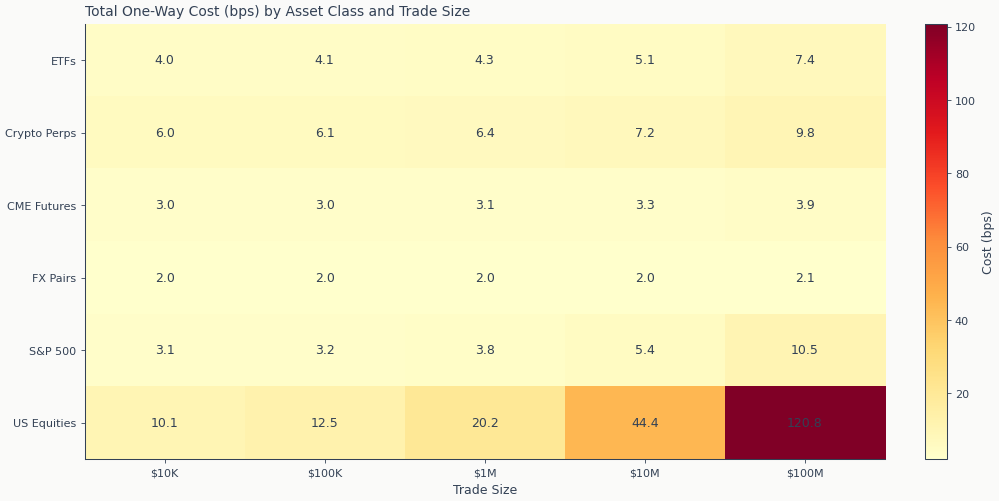

In [17]:
# Cost dominance heatmap
dom_pivot = dominance.pivot(on="trade_size", index="asset_class", values="total_bps")
# Reorder columns
col_order = ["asset_class"] + size_labels
dom_pivot = dom_pivot.select([c for c in col_order if c in dom_pivot.columns])

fig, ax = plt.subplots(figsize=(10, 5))

# Total cost heatmap
data = dom_pivot.drop("asset_class").to_numpy()
asset_names = dom_pivot["asset_class"].to_list()

im = ax.imshow(data, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(size_labels)))
ax.set_xticklabels(size_labels)
ax.set_yticks(range(len(asset_names)))
ax.set_yticklabels(asset_names)
ax.set_xlabel("Trade Size")
ax.set_title("Total One-Way Cost (bps) by Asset Class and Trade Size")

# Add text annotations
for i in range(len(asset_names)):
    for j in range(len(size_labels)):
        text_val = f"{data[i, j]:.1f}"
        ax.text(j, i, text_val, ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="Cost (bps)")
fig.subplots_adjust(left=0.14, right=0.92, top=0.9, bottom=0.14)
fig.show()

**Finding**: For small trades ($10K-$100K), the spread is the dominant
cost for equity and FX markets. At $1M+, market impact begins to
dominate — particularly for less liquid assets like small-cap equities.
Commission drives costs for crypto (taker fees dominate at all sizes)
and is comparable to spread for CME futures.

## 4. Case Study Cost Assumptions

We load all nine setup.yaml files and compare their cost configurations.

In [18]:
CASE_STUDIES = [
    "etfs",
    "crypto_perps_funding",
    "nasdaq100_microstructure",
    "sp500_equity_option_analytics",
    "us_firm_characteristics",
    "fx_pairs",
    "cme_futures",
    "sp500_options",
    "us_equities_panel",
]

setup_data = {}
for cs_id in CASE_STUDIES:
    setup_path = get_case_study_source_dir(cs_id) / "config" / "setup.yaml"
    if setup_path.exists():
        setup = yaml.safe_load(setup_path.read_text())
        setup_data[cs_id] = setup

# Display cost sections
for cs_id, setup in setup_data.items():
    costs = setup.get("costs", {})
    print(f"\n{cs_id}:")
    print(f"  Class: {costs.get('class', 'unspecified')}")
    print(f"  Components: {costs.get('components', [])}")
    if "per_leg_cost_bps_range" in costs:
        print(f"  Range: {costs['per_leg_cost_bps_range']} bps per leg")
    if "fee_schedule" in costs:
        print(f"  Fees: {costs['fee_schedule']}")


etfs:
  Class: material
  Components: []

crypto_perps_funding:
  Class: material
  Components: ['taker_fee', 'maker_fee']
  Fees: {'taker_bps': 4, 'maker_bps': 2}

nasdaq100_microstructure:
  Class: dominant
  Components: []

sp500_equity_option_analytics:
  Class: material
  Components: ['spread', 'commission', 'market_impact']
  Range: [3, 10] bps per leg

us_firm_characteristics:
  Class: material
  Components: ['spread', 'commission', 'market_impact', 'borrow_cost']
  Range: [5, 20] bps per leg

fx_pairs:
  Class: material
  Components: ['spread', 'swap_points']

cme_futures:
  Class: material
  Components: ['commission', 'spread', 'roll_slippage']

sp500_options:
  Class: dominant
  Components: {'option_spread': {'description': 'Bid-ask spread on straddle.', 'estimate_pct_of_premium': [2.0, 5.0], 'note': 'ATM options have wide spreads relative to premium.'}, 'hedge_spread': {'description': 'Bid-ask spread on underlying stock per hedge rebalance.', 'estimate_bps_of_notional': 0.5

**Finding**: The case-study config dump is a consistency check on the chapter's
own research pipeline. If the YAML assumptions differ materially across studies,
the net-performance comparisons later in the chapter should differ as well.

## 5. Breakeven Alpha Analysis

The **breakeven alpha** is the minimum gross alpha a strategy must generate
to cover its transaction costs:

$$\alpha_{\text{breakeven}} = \text{turnover} \times \frac{\text{cost}_{\text{RT}}}{10{,}000}$$

Higher turnover or higher costs raise the bar. We compute this for each
case study using realistic turnover estimates from their rebalance cadences.

### Rebalance Profile Helper

Per-rebalance turnover varies with frequency: a monthly strategy might replace 30%
of its portfolio each rebalance, while an intraday strategy adjusts only a fraction
of a percent per bar. We encode these heuristics to keep annual turnover realistic.

In [19]:
def _rebalance_profile(cadence: str) -> dict:
    """Return rebalances/year and estimated per-rebalance turnover.

    Higher-frequency strategies rebalance more often but adjust less per bar.
    We scale per-rebalance turnover inversely with frequency to keep annual
    turnover in a realistic range for each regime.
    """
    c = cadence.lower()
    if "hour" in c or "8h" in c:
        return {"rebalances": 252 * 3, "turnover_per_rebal": 0.02}
    if "15_min" in c or "minute" in c:
        return {"rebalances": 252 * 26, "turnover_per_rebal": 0.005}
    if "daily" in c:
        return {"rebalances": 252, "turnover_per_rebal": 0.05}
    if "biweekly" in c:
        return {"rebalances": 26, "turnover_per_rebal": 0.20}
    if "weekly" in c:
        return {"rebalances": 52, "turnover_per_rebal": 0.15}
    if "monthly" in c:
        return {"rebalances": 12, "turnover_per_rebal": 0.30}
    if "quarterly" in c:
        return {"rebalances": 4, "turnover_per_rebal": 0.40}
    return {"rebalances": 12, "turnover_per_rebal": 0.30}

### Round-Trip Cost Helper

In [20]:
def round_trip_cost_bps(costs: dict) -> float:
    """Normalize heterogeneous cost config formats into round-trip bps."""
    if "per_leg_cost_bps_range" in costs:
        lo, hi = costs["per_leg_cost_bps_range"]
        return lo + hi
    if "fee_schedule" in costs:
        return costs["fee_schedule"].get("taker_bps", 4) * 2
    if "round_trip_cost_bps" in costs:
        return costs["round_trip_cost_bps"]
    return 20

### Breakeven Row Helper

In [21]:
def breakeven_row(cs_id: str, setup: dict) -> dict:
    """Compute annual turnover and breakeven alpha for one case study."""
    costs = setup.get("costs", {})
    decision = setup.get("decision", {})
    cadence = (
        decision.get("entry_cadence")
        or decision.get("cadence")
        or decision.get("bar_frequency")
        or "monthly_month_end"
    )
    profile = _rebalance_profile(cadence)
    annual_rebalances = profile["rebalances"]
    annual_turnover = annual_rebalances * profile["turnover_per_rebal"]
    rt_cost_bps = round_trip_cost_bps(costs)
    be_alpha = breakeven_alpha(annual_turnover, rt_cost_bps)
    return {
        "case_study": cs_id,
        "cadence": cadence,
        "rebalances_yr": annual_rebalances,
        "est_turnover": annual_turnover,
        "rt_cost_bps": rt_cost_bps,
        "breakeven_alpha_pct": be_alpha * 100,
    }

### Compute Breakeven Alpha by Case Study

In [22]:
breakeven_rows = []
for cs_id, setup in setup_data.items():
    breakeven_rows.append(breakeven_row(cs_id, setup))

if not breakeven_rows:
    raise ValueError(
        "No case study setup data found for breakeven analysis. "
        "Expected source-controlled setup.yaml files under case_studies/*/config/."
    )

breakeven_df = pl.DataFrame(breakeven_rows).sort("breakeven_alpha_pct", descending=True)
breakeven_df

case_study,cadence,rebalances_yr,est_turnover,rt_cost_bps,breakeven_alpha_pct
str,str,i64,f64,i64,f64
"""nasdaq100_microstructure""","""15_minute""",6552,32.76,20,6.552
"""us_equities_panel""","""daily_close""",252,12.6,25,3.15
"""fx_pairs""","""daily_ny_close""",252,12.6,20,2.52
"""cme_futures""","""weekly_friday_close""",52,7.8,20,1.56
"""sp500_options""","""weekly_friday""",52,7.8,20,1.56
"""crypto_perps_funding""","""8_hour_funding_aligned""",756,15.12,8,1.2096
"""sp500_equity_option_analytics""","""weekly_friday_close""",52,7.8,13,1.014
"""us_firm_characteristics""","""monthly_month_end""",12,3.6,25,0.9
"""etfs""","""monthly_month_end""",12,3.6,20,0.72


**Finding**: The breakeven table translates microstructure assumptions into a
research hurdle rate. A strategy with modest gross alpha but high turnover can
look viable in-sample and still fail the cost-adjusted test immediately.

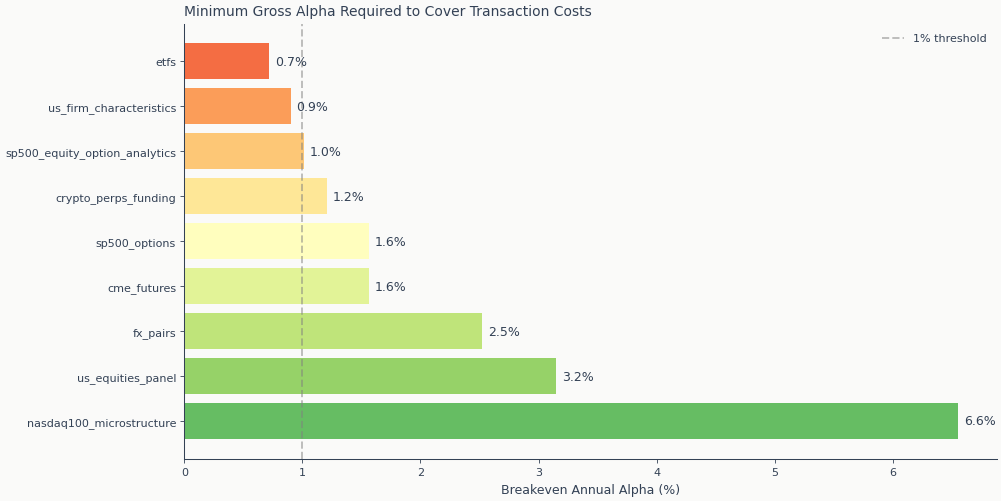

In [23]:
# Breakeven alpha heatmap
be_pd = breakeven_df.to_pandas()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(be_pd))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(be_pd)))

bars = ax.barh(x, be_pd["breakeven_alpha_pct"], color=colors)
ax.set_yticks(x)
ax.set_yticklabels(be_pd["case_study"])
ax.set_xlabel("Breakeven Annual Alpha (%)")
ax.set_title("Minimum Gross Alpha Required to Cover Transaction Costs")
ax.axvline(1.0, color="gray", linestyle="--", alpha=0.5, label="1% threshold")
ax.legend()

# Add value labels
for bar, val in zip(bars, be_pd["breakeven_alpha_pct"], strict=False):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
    )

fig.show()

**Finding**: Breakeven alpha ranges from under 1% for monthly strategies
(ETFs 0.7%, firm characteristics 0.9%) to over 6% for NASDAQ-100
intraday. Even with conservative per-rebalance turnover assumptions
(0.5% per 15-min bar, 2% per 8h bar), higher-frequency strategies face
steep cost hurdles. This is the fundamental tension between signal decay
(faster rebalancing captures more alpha) and transaction costs (each
rebalance incurs friction).

## 6. Borrow Costs for Long-Short Strategies

Several case studies use long-short construction (US equities panel,
US firm characteristics). The short leg incurs additional costs:

- **General collateral (GC)**: ~25-50 bps/year for liquid stocks
- **Special/hard-to-borrow**: 100-1000+ bps/year for crowded shorts
- **Rebate rate**: Offsetting interest on short sale proceeds

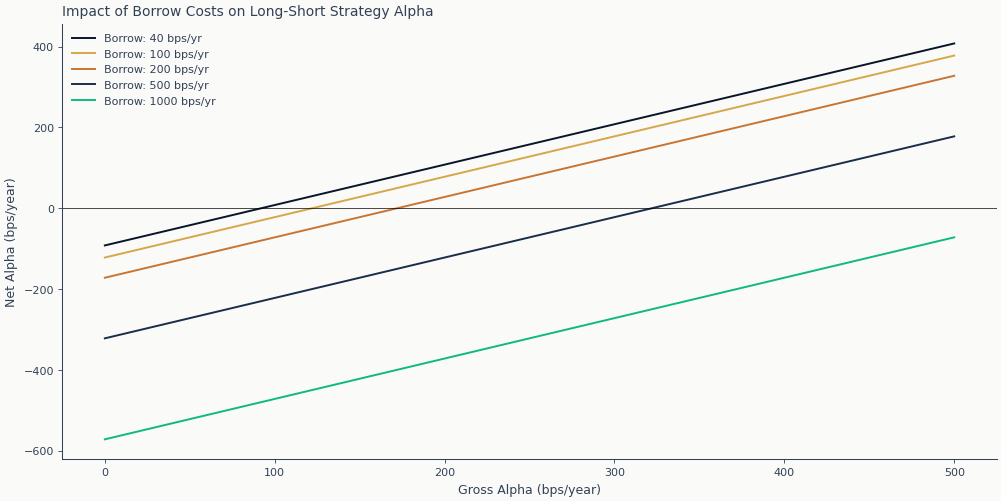

In [24]:
# Illustrate borrow cost impact on long-short strategies
borrow_rates = [40, 100, 200, 500, 1000]  # bps/year: GC through hard-to-borrow

gross_alphas = np.linspace(0, 500, 100)  # bps

fig, ax = plt.subplots(figsize=(10, 5))
for borrow_bps in borrow_rates:
    # Net alpha = gross - (trading costs + borrow costs)
    # Assume 20 bps RT trading cost, monthly rebalance, 30% turnover per rebalance
    trading_cost_drag = 12 * 0.30 * 20  # 72 bps annualized
    net_alpha = gross_alphas - trading_cost_drag - borrow_bps / 2  # Half portfolio is short
    ax.plot(gross_alphas, net_alpha, label=f"Borrow: {borrow_bps} bps/yr")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Gross Alpha (bps/year)")
ax.set_ylabel("Net Alpha (bps/year)")
ax.set_title("Impact of Borrow Costs on Long-Short Strategy Alpha")
ax.legend(loc="upper left")

fig.show()

**Finding**: For a strategy with 200 bps gross alpha, borrow costs on the
short leg (half portfolio) consume 10% of alpha at general collateral rates
(40 bps/yr) but 50%+ at hard-to-borrow rates (200+ bps/yr). Combined with
72 bps of annual trading cost drag, strategies with moderate gross alpha can
easily turn net-negative. The `us_equities_panel` and
`us_firm_characteristics` setup.yaml files correctly flag borrow costs as a
material component.

## Key Takeaways

1. **Fee schedules vary widely**: From CME futures (under 1 bps) to
   crypto taker fees (4 bps) to option per-contract fees (20 bps).
   Exchange fees alone rarely dominate total costs except for options.

2. **Spread dominates at small sizes, impact at large**: For most asset
   classes, the bid-ask spread is the primary cost up to ~$100K;
   market impact takes over for institutional-scale trades.

3. **Breakeven alpha scales with frequency**: Daily strategies require
   3-4x the gross alpha of monthly strategies. Intraday strategies
   (NASDAQ-100) face breakeven thresholds above 6%, a steep hurdle
   that only high-capacity, low-cost strategies can clear.

4. **Borrow costs matter for long-short**: Short-leg financing adds
   25-500+ bps/year depending on stock borrow difficulty.

**Next**: See `02_spread_estimation` for empirical spread estimates
and `03_market_impact_calibration` for impact model calibration.

**Book**: Chapter 18.1-18.2 provides the theoretical framework for
cost decomposition.